# Notebook 10 — Hedge ratio óptimo y reducción de riesgo del productor

Con las primas calculadas en los notebooks 08–09, este notebook responde la pregunta operativa: **¿cuánto del riesgo del productor cubren estos contratos?** Para cada combinación viable de (zona, semestre, contrato), se calcula el **hedge ratio óptimo de mínima varianza** $h^*$ y se cuantifica la reducción de VaR y CVaR del ingreso al comprar los contratos.

## Marco

**Modelo del ingreso del productor**. El productor cultiva $A$ hectáreas, obtiene un rendimiento $Y$ (t/ha) que depende del clima, y vende a precio fijo $P$ (USD/t):

$$I = P \cdot Y \cdot A$$

El rendimiento se modela como función lineal de los índices climáticos:

$$Y = \alpha + \beta_{\text{HDD}} \cdot \text{HDD} + \beta_{\text{CRI}} \cdot \text{CRI} + \delta_{\text{fase}} + \varepsilon$$

con $\beta_{\text{HDD}} < 0$ (más estrés térmico → menor rendimiento) y $\beta_{\text{CRI}}$ con signo dependiente del régimen pluvial (positivo si la lluvia es escasa, negativo si abunda).

**Hedge ratio óptimo (univariado)**. Para un contrato individual con payoff $P_C$, el número óptimo de unidades que minimiza la varianza del ingreso neto es:

$$h^* = \frac{\text{Cov}(I, P_C)}{\text{Var}(P_C)}$$

estimado sobre las trayectorias Monte Carlo del notebook 06–07. Equivalentemente, $h^*$ es el **tick natural** del contrato: el monto en USD por unidad de índice climático que compensa exactamente la pérdida marginal del productor (ver discusión en el chat).

**Ingreso neto al madurar el contrato**:

$$I^{\text{net}} = I + h^* \cdot P_C - h^* \cdot \Pi \cdot e^{rT}$$

donde $\Pi$ es la prima pagada al inicio (decisión del 09: usar $\lambda = 0.5$).

**Reducción de riesgo** se reporta vía:

$$\text{Var. Reduction} = 1 - \frac{\text{Var}(I^{\text{net}})}{\text{Var}(I)}, \quad
\Delta \text{VaR} = \text{VaR}(I) - \text{VaR}(I^{\text{net}})$$

al 95% y 99%.

### Decisiones operativas

| Parámetro | Valor | Justificación |
|---|---|---|
| Notional $A$ | 1 ha | Reporte unitario; productor escala a su finca |
| Precio arroz $P$ | 350 USD/t | Referencia Fedearroz 2024-25 (precio paddy verde) |
| Sistema | Riego | Más data, sistema relevante para derivados |
| Tasa $r$ | 10% anual continua | Consistente con notebook 08 |
| Horizonte $T$ | 40 días | Ventana fenológica |
| $\lambda$ ref | 0.5 | Decisión del notebook 09 |
| Contratos | 3 viables | Casanare A Put se reporta pero **no se ofrece** (ratio invertido del 08) |

### Análisis condicional por fase ENSO

Como la fase ENSO se conoce ex-ante con meses de anticipación (NOAA emite pronósticos RONI mensuales), reportamos el hedge ratio **por fase**. El productor toma la decisión de cobertura conociendo el escenario probable.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

OUT_DIR = Path("../data/processed")

# Parámetros operativos
PRECIO_ARROZ = 350.0     # USD/t (paddy verde, Fedearroz 2024-25)
AREA_HA      = 1.0       # 1 ha como notional unitario
r            = 0.10
T_anios      = 40 / 365
DF           = np.exp(-r * T_anios)
CAPITAL      = np.exp(r * T_anios)   # factor de capitalización de la prima al madurar
T_STAR_HDD   = 28
LAMBDA_REF   = 0.05      # decisión del notebook 09

ALFA_VAR     = [0.05, 0.01]   # niveles para VaR/CVaR

# Mapeo zona arrocera Fedearroz ↔ departamento del modelo
ZONA_DEPARTAMENTO = {"Centro": "Tolima", "Llanos": "Casanare"}

print(f"Precio arroz = {PRECIO_ARROZ} USD/t  |  Notional = {AREA_HA} ha")
print(f"r = {r:.2%}/año  |  T = {T_anios*365:.0f} días  |  DF = {DF:.4f}  |  Capitalización = {CAPITAL:.4f}")
print(f"λ de referencia (notebook 09) = {LAMBDA_REF}")

Precio arroz = 350.0 USD/t  |  Notional = 1.0 ha
r = 10.00%/año  |  T = 40 días  |  DF = 0.9891  |  Capitalización = 1.0110
λ de referencia (notebook 09) = 0.05


## 1. Carga de datos

In [2]:
# Índices simulados (notebook 07)
indices = pd.read_parquet(OUT_DIR / "indices.parquet")

# Precios (notebook 09 con λ=0.5; baseline λ=0 desde notebook 08)
precios_baseline = pd.read_csv(OUT_DIR / "precios_contratos.csv")
precios_lambda   = pd.read_csv(OUT_DIR / "precios_lambda_sensibilidad.csv")
bias             = pd.read_csv(OUT_DIR / "bias_diagnostico.csv")
bias_dict = {(row.dpto, row.semestre, row.fase): row.k_correccion for row in bias.itertuples()}

# Datos históricos consolidados (Base_Final ya tiene rendimientos + clima agregado)
base_final = pd.read_excel("../data/processed/Modelo_Completo.xlsx", sheet_name="Base_Final")
# Solo riego (decisión operativa) y solo zonas con datos del modelo (Centro = Tolima, Llanos = Casanare)
base_final = base_final[(base_final["system"] == "riego")
                        & (base_final["zone"].isin(ZONA_DEPARTAMENTO.keys()))].copy()
print(f"Base_Final filtrada (riego, Centro+Llanos): {base_final.shape}")
print(base_final[["zone", "year", "semester", "fase", "rendimiento", "t_mean", "precip"]].head().to_string(index=False))

Base_Final filtrada (riego, Centro+Llanos): (62, 15)
  zone  year  semester   fase  rendimiento    t_mean      precip
Llanos  2010         1   Niño          5.3 27.430929 1368.447901
Llanos  2010         2   Niña          5.6 26.160734 1396.104606
Llanos  2011         1   Niña          5.1 26.380239 1506.920282
Llanos  2011         2   Niña          4.0 25.883158 1428.355593
Llanos  2012         1 Neutro          4.9 26.140963 1336.722949


## 2. Calibración de la relación rendimiento ~ índices climáticos

Sobre la base histórica (16 años × 2 semestres por zona = 32 obs por zona), se estima la regresión:

$$Y_{z,t} = \alpha_z + \beta^{(z)}_{\text{HDD}} \cdot \text{HDD}^{\text{hist}}_{z,t} + \beta^{(z)}_{\text{CRI}} \cdot \text{CRI}^{\text{hist}}_{z,t} + \delta^{(z)}_{\text{semestre}} + \varepsilon$$

Primero hay que calcular $\text{HDD}^{\text{hist}}$ y $\text{CRI}^{\text{hist}}$ sobre las ventanas fenológicas históricas — `Base_Final` trae solo agregados semestrales, no sobre la ventana específica. Recalculo desde el clima diario.

In [3]:
DIA_INICIO_VENTANA = 60
DURACION_VENTANA   = 40
CALENDARIO = {
    "Tolima":   {"A": "03-15", "B": "08-15"},
    "Casanare": {"A": "04-15", "B": "08-15"},
}

df_hist = pd.read_excel("../data/processed/Modelo_Completo.xlsx",
                        parse_dates=["date"]).set_index("date")

def indices_historicos_por_anio(df_hist_dpto, dpto):
    """Calcula HDD_28 y CRI sobre la ventana fenológica para cada año × semestre."""
    salida = []
    for sem, mm_dd in CALENDARIO[dpto].items():
        mes, dia = map(int, mm_dd.split("-"))
        for anio in sorted(set(df_hist_dpto.index.year)):
            inicio = pd.Timestamp(f"{anio}-{mes:02d}-{dia:02d}") + pd.Timedelta(days=DIA_INICIO_VENTANA)
            fin    = inicio + pd.Timedelta(days=DURACION_VENTANA - 1)
            win = df_hist_dpto.loc[inicio:fin]
            if len(win) < DURACION_VENTANA * 0.8: continue
            salida.append({
                "dpto": dpto, "year": anio, "semester": 1 if sem == "A" else 2,
                "HDD_28": float(np.maximum(win["t_mean"].values - T_STAR_HDD, 0).sum()),
                "CRI":    float(win["precip"].sum()),
            })
    return pd.DataFrame(salida)

indices_hist = []
for dpto in ["Tolima", "Casanare"]:
    sub = df_hist[df_hist["department"] == dpto][["t_mean", "precip"]].copy()
    indices_hist.append(indices_historicos_por_anio(sub, dpto))
indices_hist_df = pd.concat(indices_hist, ignore_index=True)

# Unir con rendimientos: mapear zone -> dpto
base_riego = base_final.copy()
base_riego["dpto"] = base_riego["zone"].map(ZONA_DEPARTAMENTO)
modelo_df = base_riego.merge(indices_hist_df, on=["dpto", "year", "semester"], how="inner")
modelo_df["semestre_str"] = modelo_df["semester"].map({1: "A", 2: "B"})
print(f"Tabla rendimiento ~ índices: {modelo_df.shape}")
print(modelo_df[["dpto", "zone", "year", "semestre_str", "fase", "rendimiento", "HDD_28", "CRI"]].head().to_string(index=False))

Tabla rendimiento ~ índices: (62, 19)
    dpto   zone  year semestre_str   fase  rendimiento  HDD_28        CRI
Casanare Llanos  2010            A   Niño          5.3     0.0 421.738603
Casanare Llanos  2010            B   Niña          5.6     0.0 308.248906
Casanare Llanos  2011            A   Niña          5.1     0.0 404.951778
Casanare Llanos  2011            B   Niña          4.0     0.0 324.894036
Casanare Llanos  2012            A Neutro          4.9     0.0 427.800000


### Regresión OLS por zona

Estimamos un modelo OLS por zona con regresores `HDD_28`, `CRI`, y dummy de semestre (A vs B). Las dummies de fase ENSO se omiten porque ya están **embebidas en los índices** — el clima de un año Niño se refleja directamente en valores de HDD/CRI distintos. Agregar la fase como dummy sería capturar el mismo efecto dos veces.

In [4]:
def ajustar_modelo_rendimiento(df_zona, etiqueta):
    """OLS: rendimiento = α + β_HDD·HDD + β_CRI·CRI + δ·sem_B + ε"""
    X = pd.DataFrame({
        "HDD_28": df_zona["HDD_28"].values,
        "CRI":    df_zona["CRI"].values,
        "sem_B":  (df_zona["semester"] == 2).astype(float).values,
    })
    X = sm.add_constant(X)
    y = df_zona["rendimiento"].values
    m = sm.OLS(y, X).fit()
    print(f"\n=== {etiqueta} (n = {len(df_zona)}) ===")
    print(f"  R² = {m.rsquared:.3f}   R²_adj = {m.rsquared_adj:.3f}")
    print(f"  α = {m.params['const']:.3f}    σ_resid = {np.sqrt(m.mse_resid):.4f}")
    print(f"  β_HDD = {m.params['HDD_28']:+.4f}  (p = {m.pvalues['HDD_28']:.3f})")
    print(f"  β_CRI = {m.params['CRI']:+.5f}  (p = {m.pvalues['CRI']:.3f})")
    print(f"  δ_sem_B = {m.params['sem_B']:+.3f}  (p = {m.pvalues['sem_B']:.3f})")
    return m

modelos = {}
for dpto in ["Tolima", "Casanare"]:
    sub = modelo_df[modelo_df["dpto"] == dpto].copy()
    modelos[dpto] = ajustar_modelo_rendimiento(sub, dpto)


=== Tolima (n = 31) ===
  R² = 0.206   R²_adj = 0.149
  α = 6.601    σ_resid = 0.3657
  β_HDD = +0.0000  (p = 0.000)
  β_CRI = +0.00138  (p = 0.187)
  δ_sem_B = +0.173  (p = 0.300)

=== Casanare (n = 31) ===
  R² = 0.221   R²_adj = 0.135
  α = 5.188    σ_resid = 0.4182
  β_HDD = +1.0883  (p = 0.358)
  β_CRI = +0.00066  (p = 0.495)
  δ_sem_B = -0.270  (p = 0.298)


**Interpretación de los $\beta$**: cada unidad de HDD₂₈ adicional (°C·día acumulado sobre 32 °C) reduce el rendimiento en $|\beta_{\text{HDD}}|$ t/ha; cada milímetro adicional de lluvia en la ventana cambia el rendimiento en $|\beta_{\text{CRI}}|$ t/ha (signo depende de la zona).

Los $R^2$ son típicamente modestos (0.2–0.5) en datos de rendimientos agrícolas — el rendimiento depende también de manejo, plagas, variedad y otros factores no climáticos.

## 3. Simulación del ingreso del productor sobre las trayectorias MC

Para cada trayectoria $i$, aplicamos la regresión a los índices simulados (con corrección de bias en CRI) y agregamos el ruido residual de la regresión:

$$Y^{(i)} = \alpha + \beta_{\text{HDD}} \cdot \text{HDD}^{(i)} + \beta_{\text{CRI}} \cdot \text{CRI}^{(i)} + \delta_{\text{sem}} + \varepsilon^{(i)}$$
$$I^{(i)} = P_{\text{arroz}} \cdot Y^{(i)} \cdot A$$

El ruido $\varepsilon \sim \mathcal{N}(0, \sigma_{\text{resid}})$ captura la incertidumbre no climática del rendimiento.

In [5]:
def simular_ingreso(indices_dpto, modelo, dpto, semestre, seed=42):
    """Aplica la regresión a las trayectorias MC y devuelve DataFrame con
    rendimiento e ingreso por (path_id, fase ENSO simulada)."""
    rng = np.random.default_rng(seed)
    sigma_resid = float(np.sqrt(modelo.mse_resid))
    sem_dummy = 1.0 if semestre == "B" else 0.0

    rows = []
    for fase in ["Niño", "Neutro", "Niña"]:
        sub = indices_dpto[(indices_dpto["semestre"] == semestre) & (indices_dpto["fase"] == fase)]
        if sub.empty: continue
        # Corrección de bias en CRI (decisión del 08)
        k = bias_dict.get((dpto, semestre, fase), 1.0)
        cri_corr = sub["CRI"].values * k
        hdd_vals = sub["HDD_28"].values

        # Aplicar regresión
        y_hat = (modelo.params["const"]
                 + modelo.params["HDD_28"] * hdd_vals
                 + modelo.params["CRI"]    * cri_corr
                 + modelo.params["sem_B"]  * sem_dummy)
        # Ruido residual
        eps = rng.normal(0, sigma_resid, size=len(y_hat))
        y_sim = np.clip(y_hat + eps, 0, None)   # rendimiento no puede ser negativo
        ingreso = PRECIO_ARROZ * y_sim * AREA_HA

        rows.append(pd.DataFrame({
            "dpto": dpto, "semestre": semestre, "fase": fase,
            "path_id": sub["path_id"].values,
            "HDD_28": hdd_vals, "CRI_corregido": cri_corr,
            "rendimiento_sim": y_sim, "ingreso_sim": ingreso,
        }))
    return pd.concat(rows, ignore_index=True)

ingresos = []
for dpto in ["Tolima", "Casanare"]:
    for sem in ["A", "B"]:
        sub_idx = indices[indices["dpto"] == dpto]
        ingresos.append(simular_ingreso(sub_idx, modelos[dpto], dpto, sem))
ingresos_df = pd.concat(ingresos, ignore_index=True)

print(f"Tabla de ingresos simulados: {ingresos_df.shape}")
print("\nIngreso bruto por (dpto, semestre, fase) — media y std (USD/ha):")
print(ingresos_df.groupby(["dpto", "semestre", "fase"], observed=True)
                  .agg(ingreso_medio=("ingreso_sim", "mean"),
                       ingreso_std=("ingreso_sim", "std"))
                  .round(1)
                  .to_string())

Tabla de ingresos simulados: (120000, 8)

Ingreso bruto por (dpto, semestre, fase) — media y std (USD/ha):
                          ingreso_medio  ingreso_std
dpto     semestre fase                              
Casanare A        Neutro         1961.8        214.6
                  Niña           1966.4        202.8
                  Niño           2037.7        295.5
         B        Neutro         2138.6        509.7
                  Niña           2037.3        417.6
                  Niño           2455.1        800.6
Tolima   A        Neutro         2409.0        136.6
                  Niña           2465.1        139.7
                  Niño           2401.4        141.7
         B        Neutro         2515.0        139.8
                  Niña           2534.9        137.5
                  Niño           2506.4        144.4


## 4. Cálculo del hedge ratio óptimo de mínima varianza

Para cada contrato viable y cada (dpto, semestre, fase), se calcula $h^* = \text{Cov}(I, P_C) / \text{Var}(P_C)$ sobre los 1000 paths simulados.

In [6]:
# Strikes derivados en el notebook 08 (mismos cuantiles del histórico Neutro)
# Los re-derivamos aquí para que el notebook sea autocontenido
def strikes_neutro_hist(df_hist_dpto, dpto):
    salida = {}
    for sem, mm_dd in CALENDARIO[dpto].items():
        mes, dia = map(int, mm_dd.split("-"))
        serie_hdd, serie_cri = [], []
        for anio in sorted(set(df_hist_dpto.index.year)):
            inicio = pd.Timestamp(f"{anio}-{mes:02d}-{dia:02d}") + pd.Timedelta(days=DIA_INICIO_VENTANA)
            fin    = inicio + pd.Timedelta(days=DURACION_VENTANA - 1)
            win = df_hist_dpto.loc[inicio:fin]
            if len(win) < DURACION_VENTANA * 0.8: continue
            fase_w = win["fase"].mode().iloc[0] if not win["fase"].mode().empty else None
            if fase_w != "Neutro": continue
            serie_hdd.append(float(np.maximum(win["t_mean"].values - T_STAR_HDD, 0).sum()))
            serie_cri.append(float(win["precip"].sum()))
        salida[sem] = {
            "K_call_HDD": float(np.quantile(serie_hdd, 0.75)),
            "K_put_CRI":  float(np.quantile(serie_cri, 0.25)),
            "K_call_CRI": float(np.quantile(serie_cri, 0.90)),
        }
    return salida

enso = pd.read_excel("../data/processed/Modelo_Completo.xlsx", sheet_name="CapaB_ENSO")
enso["date"] = pd.to_datetime(enso["date"])
enso_daily = enso.set_index("date")[["fase"]].resample("D").ffill()
hist_por_dpto = {}
for dpto in ["Tolima", "Casanare"]:
    sub = df_hist[df_hist["department"] == dpto][["t_mean", "precip"]].copy()
    sub = sub.join(enso_daily, how="left").dropna()
    hist_por_dpto[dpto] = sub
strikes = {dpto: strikes_neutro_hist(hist_por_dpto[dpto], dpto) for dpto in ["Tolima", "Casanare"]}


def precios_para(dpto, sem, fase, lam=LAMBDA_REF):
    """Devuelve diccionario {contrato: prima} para un grupo, leído de precios_lambda."""
    sub = precios_lambda[(precios_lambda["dpto"] == dpto)
                          & (precios_lambda["semestre"] == sem)
                          & (precios_lambda["fase"] == fase)
                          & (precios_lambda["lambda"] == lam)]
    return {row.contrato: row.precio for row in sub.itertuples()}


# Definición de payoffs por contrato (al madurar, NO descontado)
def payoffs_contrato(ingresos_grupo, contrato, K):
    """Payoff al madurar, no descontado: max(I_idx - K, 0) ó max(K - I_idx, 0)."""
    if contrato == "Call HDD_28":
        return np.maximum(ingresos_grupo["HDD_28"].values - K, 0.0)
    if contrato == "Put CRI":
        return np.maximum(K - ingresos_grupo["CRI_corregido"].values, 0.0)
    if contrato == "Call CRI":
        return np.maximum(ingresos_grupo["CRI_corregido"].values - K, 0.0)
    raise ValueError(contrato)


def hedge_optimo_univariado(I, payoff):
    """h* = Cov(I, P) / Var(P) — minimiza Var(I + h·P)."""
    var_p = np.var(payoff, ddof=1)
    if var_p <= 1e-12:
        return 0.0, 0.0
    cov = np.cov(I, payoff, ddof=1)[0, 1]
    # Para HEDGE de un activo riesgoso (no especulación): minimiza Var(I - h_short·P)
    # i.e. el productor está LONG en el contrato → h* = -Cov(I,P)/Var(P).
    # Como I sube cuando el clima es bueno y P paga cuando es malo, Cov(I,P) < 0
    # → h* > 0. Reportamos h* en magnitud positiva (número de contratos largos).
    h_estrella = -cov / var_p
    rho = cov / (np.sqrt(np.var(I, ddof=1) * var_p) + 1e-12)
    return h_estrella, rho

### Decisión de qué contrato corresponde a cada fase

Para cada fase ENSO, se compra el contrato cuyo escenario adverso es **esa misma fase**:

| Fase | Contrato natural |
|---|---|
| Niño | Call HDD₂₈ y/o Put CRI |
| Neutro | Sin cobertura típicamente (pero reportamos por completitud) |
| Niña | Call CRI |

In [7]:
CONTRATOS = [
    {"nombre": "Call HDD_28", "K_key": "K_call_HDD", "fase_objetivo": "Niño"},
    {"nombre": "Put CRI",     "K_key": "K_put_CRI",  "fase_objetivo": "Niño"},
    {"nombre": "Call CRI",    "K_key": "K_call_CRI", "fase_objetivo": "Niña"},
]


def evaluar_hedge_grupo(ingresos_grupo, dpto, sem, fase):
    """Calcula h* y métricas de riesgo para los 3 contratos en este grupo."""
    I = ingresos_grupo["ingreso_sim"].values
    primas = precios_para(dpto, sem, fase, lam=LAMBDA_REF)

    filas = []
    var_I  = np.var(I, ddof=1)
    var95_I  = np.quantile(I, ALFA_VAR[0])
    var99_I  = np.quantile(I, ALFA_VAR[1])
    cvar95_I = I[I <= var95_I].mean() if (I <= var95_I).any() else var95_I
    cvar99_I = I[I <= var99_I].mean() if (I <= var99_I).any() else var99_I

    for ctto in CONTRATOS:
        K = strikes[dpto][sem][ctto["K_key"]]
        payoff = payoffs_contrato(ingresos_grupo, ctto["nombre"], K)
        h, rho = hedge_optimo_univariado(I, payoff)
        # Si h <= 0, no hay cobertura útil — el productor NO compra el contrato.
        # Reportamos el resultado pero etiquetamos.
        Pi = primas.get(ctto["nombre"], 0.0)
        costo_capitalizado = h * Pi * CAPITAL
        I_net = I + h * payoff - costo_capitalizado

        var_net  = np.var(I_net, ddof=1)
        var95    = np.quantile(I_net, ALFA_VAR[0])
        var99    = np.quantile(I_net, ALFA_VAR[1])
        cvar95   = I_net[I_net <= var95].mean() if (I_net <= var95).any() else var95
        cvar99   = I_net[I_net <= var99].mean() if (I_net <= var99).any() else var99

        filas.append({
            "dpto": dpto, "semestre": sem, "fase": fase,
            "contrato": ctto["nombre"],
            "strike": K, "prima": Pi,
            "h_optimo": h, "correlacion": rho,
            "viable": h > 0,
            # Riesgo sin cobertura (referencia)
            "ingreso_medio": I.mean(),
            "var95_sin":  var95_I, "var99_sin":  var99_I,
            "cvar95_sin": cvar95_I, "cvar99_sin": cvar99_I,
            "std_sin":    np.sqrt(var_I),
            # Riesgo con cobertura
            "ingreso_medio_net": I_net.mean(),
            "var95_con":  var95, "var99_con":  var99,
            "cvar95_con": cvar95, "cvar99_con": cvar99,
            "std_con":    np.sqrt(var_net),
            # Métricas comparativas
            "var_reduction_pct":   100 * (1 - var_net / var_I),
            "delta_var95":         var95 - var95_I,      # ↑ = mejora (menos pérdida en cola)
            "delta_cvar95":        cvar95 - cvar95_I,
            "delta_var99":         var99 - var99_I,
            "delta_cvar99":        cvar99 - cvar99_I,
        })
    return pd.DataFrame(filas)


resultados = []
for dpto in ["Tolima", "Casanare"]:
    for sem in ["A", "B"]:
        for fase in ["Niño", "Neutro", "Niña"]:
            sub = ingresos_df[(ingresos_df["dpto"] == dpto)
                              & (ingresos_df["semestre"] == sem)
                              & (ingresos_df["fase"] == fase)]
            if sub.empty: continue
            resultados.append(evaluar_hedge_grupo(sub, dpto, sem, fase))

hedge_df = pd.concat(resultados, ignore_index=True)
print(f"Tabla de hedge: {hedge_df.shape}")

Tabla de hedge: (36, 26)


## 5. Resultados principales: hedge ratios óptimos por contrato y fase

Las tablas muestran el $h^*$ con su correlación rendimiento-payoff, la viabilidad como cobertura (h > 0), y la prima.

In [8]:
for ctto_nombre, fase_obj in [("Call HDD_28", "Niño"), ("Put CRI", "Niño"), ("Call CRI", "Niña")]:
    sub = hedge_df[(hedge_df["contrato"] == ctto_nombre) & (hedge_df["fase"] == fase_obj)]
    if sub.empty: continue
    print(f"\n{'='*86}")
    print(f"{ctto_nombre} — fase objetivo: {fase_obj}  (prima con λ={LAMBDA_REF})")
    print('='*86)
    cols = ["dpto", "semestre", "strike", "prima", "h_optimo", "correlacion", "viable"]
    print(sub[cols].round(3).to_string(index=False))


Call HDD_28 — fase objetivo: Niño  (prima con λ=0.05)
    dpto semestre  strike  prima  h_optimo  correlacion  viable
  Tolima        A   0.000  0.807    -1.493        0.015   False
  Tolima        B   0.000  0.489     0.109       -0.001    True
Casanare        A   0.000  0.261  -377.173        0.865   False
Casanare        B   0.187  1.645  -385.123        0.982   False

Put CRI — fase objetivo: Niño  (prima con λ=0.05)
    dpto semestre  strike  prima  h_optimo  correlacion  viable
  Tolima        A 189.612 48.450     0.882       -0.328    True
  Tolima        B 284.630 54.665     0.796       -0.365    True
Casanare        A 427.782  0.989     0.802       -0.017    True
Casanare        B 252.246 55.297     0.220       -0.014    True

Call CRI — fase objetivo: Niña  (prima con λ=0.05)
    dpto semestre  strike  prima  h_optimo  correlacion  viable
  Tolima        A 231.230 98.971    -0.550        0.381   False
  Tolima        B 303.081 58.023    -0.623        0.337   False
Casanare  

## 6. Reducción de VaR/CVaR del ingreso del productor

Comparamos los cuantiles del ingreso **sin cobertura** ($I$) vs. **con cobertura** ($I^{\text{net}}$) al 95% y 99%. Solo se aplica la cobertura cuando $h^* > 0$ (contrato viable).

In [9]:
def tabla_riesgo(hedge_df, fase_filtro=None):
    """Tabla compacta de reducción de riesgo. Si fase_filtro, filtra a esa fase."""
    sub = hedge_df.copy()
    if fase_filtro:
        sub = sub[sub["fase"] == fase_filtro]
    sub = sub[sub["viable"]]   # solo contratos viables

    cols = ["dpto", "semestre", "fase", "contrato",
            "h_optimo", "var95_sin", "var95_con", "delta_var95",
            "cvar95_sin", "cvar95_con", "delta_cvar95",
            "var_reduction_pct"]
    return sub[cols]


print("Reducción de riesgo SOLO contratos viables (h* > 0):\n")
for fase_obj in ["Niño", "Niña"]:
    contratos_fase = {"Niño": ["Call HDD_28", "Put CRI"], "Niña": ["Call CRI"]}[fase_obj]
    for ctto in contratos_fase:
        sub = hedge_df[(hedge_df["contrato"] == ctto) & (hedge_df["fase"] == fase_obj) & (hedge_df["viable"])]
        if sub.empty: continue
        print(f"\n--- {ctto} en fase {fase_obj} ---")
        cols_show = ["dpto", "semestre", "h_optimo", "ingreso_medio", "ingreso_medio_net",
                     "std_sin", "std_con", "var_reduction_pct",
                     "var95_sin", "var95_con", "delta_var95"]
        print(sub[cols_show].round(2).to_string(index=False))

Reducción de riesgo SOLO contratos viables (h* > 0):


--- Call HDD_28 en fase Niño ---
  dpto semestre  h_optimo  ingreso_medio  ingreso_medio_net  std_sin  std_con  var_reduction_pct  var95_sin  var95_con  delta_var95
Tolima        B      0.11        2506.44            2506.44   144.36   144.36                0.0    2272.59    2272.67         0.08

--- Put CRI en fase Niño ---
    dpto semestre  h_optimo  ingreso_medio  ingreso_medio_net  std_sin  std_con  var_reduction_pct  var95_sin  var95_con  delta_var95
  Tolima        A      0.88        2401.37            2399.45   141.74   133.89              10.77    2170.71    2183.74        13.03
  Tolima        B      0.80        2506.44            2506.10   144.36   134.38              13.34    2272.59    2289.94        17.35
Casanare        A      0.80        2037.69            2037.59   295.54   295.49               0.03    1724.26    1724.96         0.70
Casanare        B      0.22        2455.14            2454.71   800.57   800.49   

## 7. Visualización: distribución del ingreso con vs sin cobertura

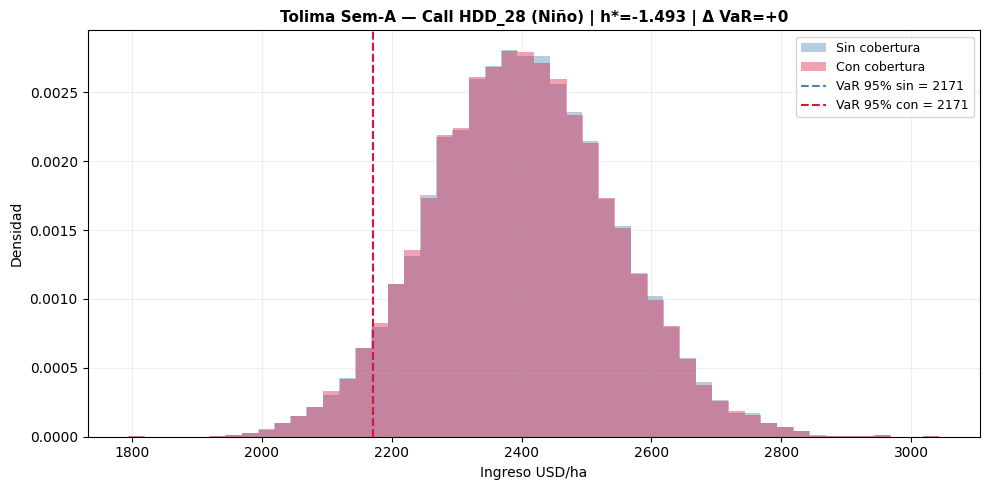

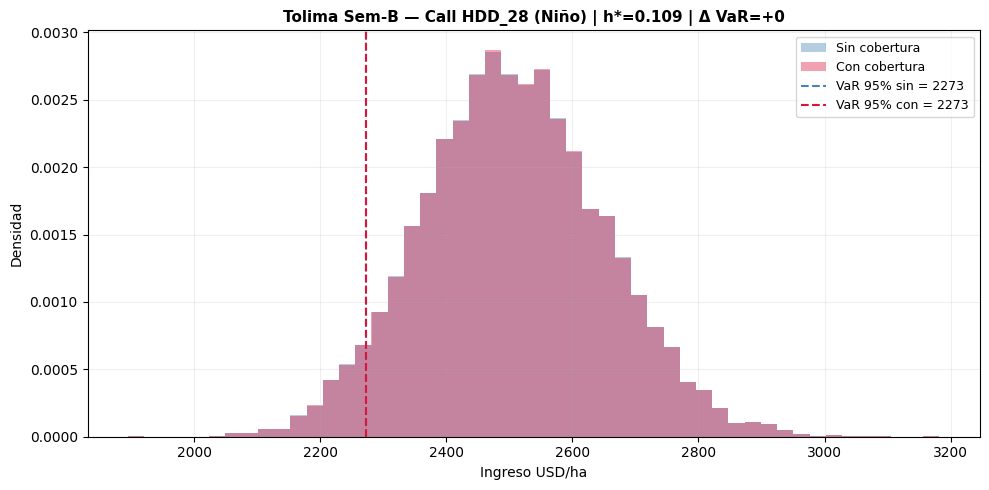

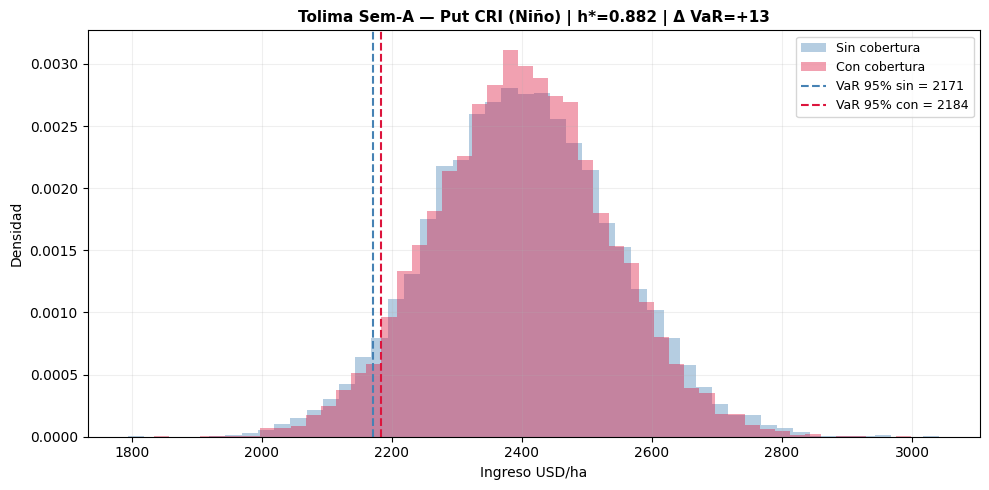

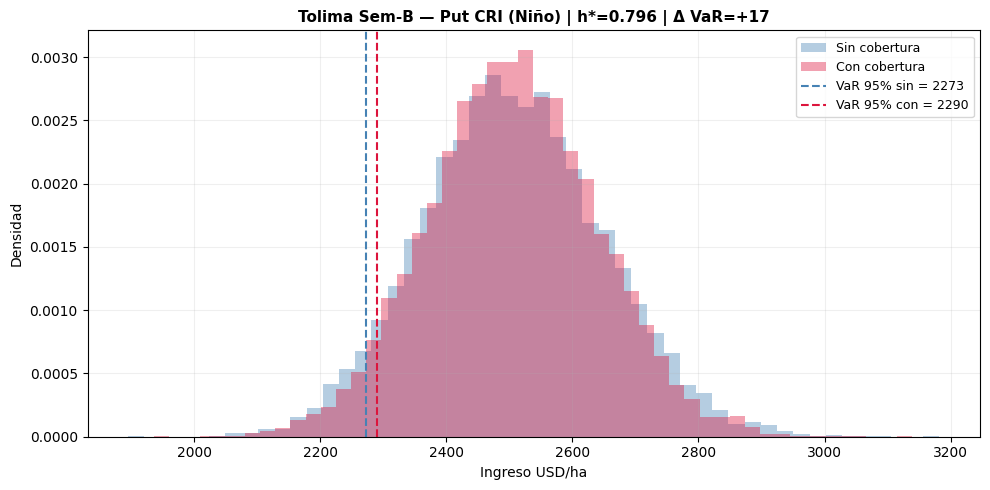

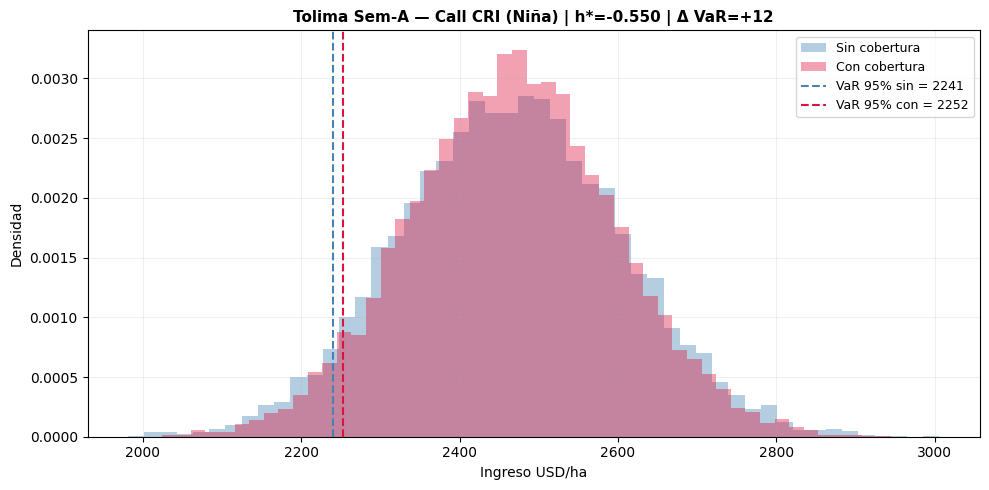

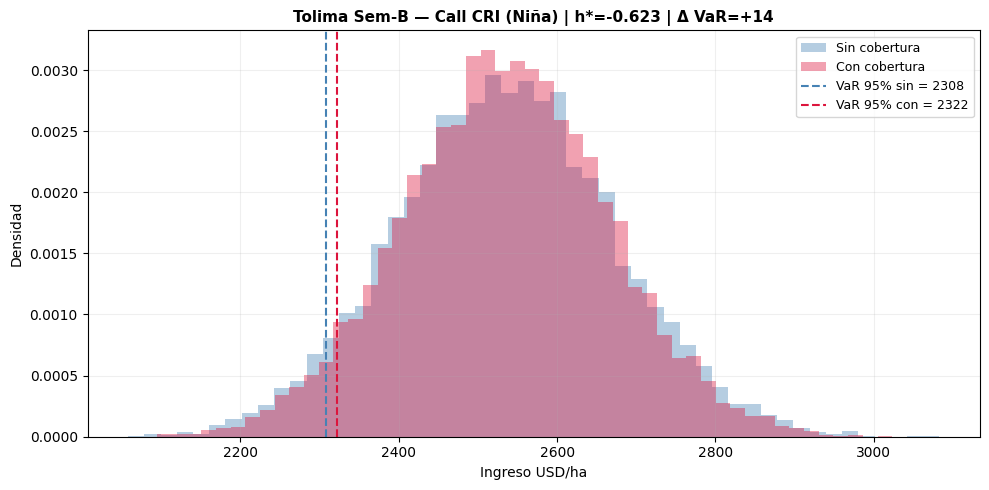

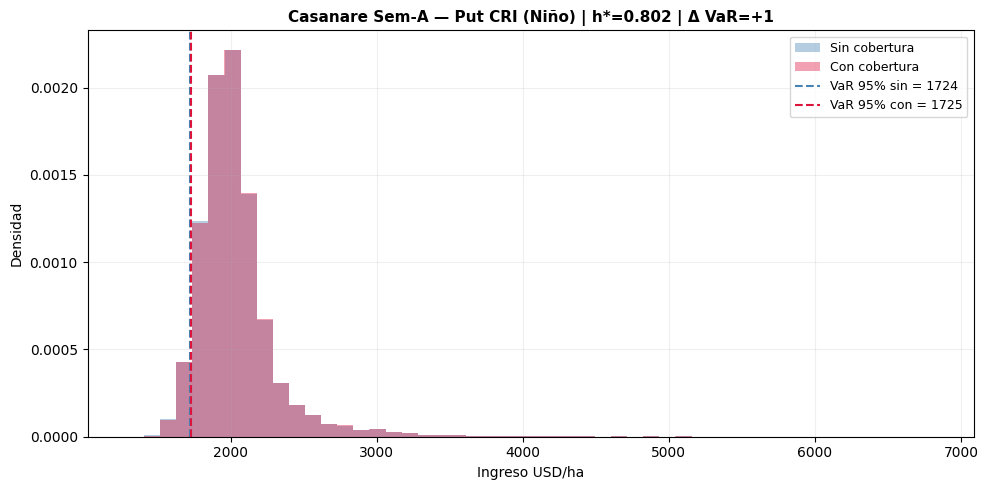

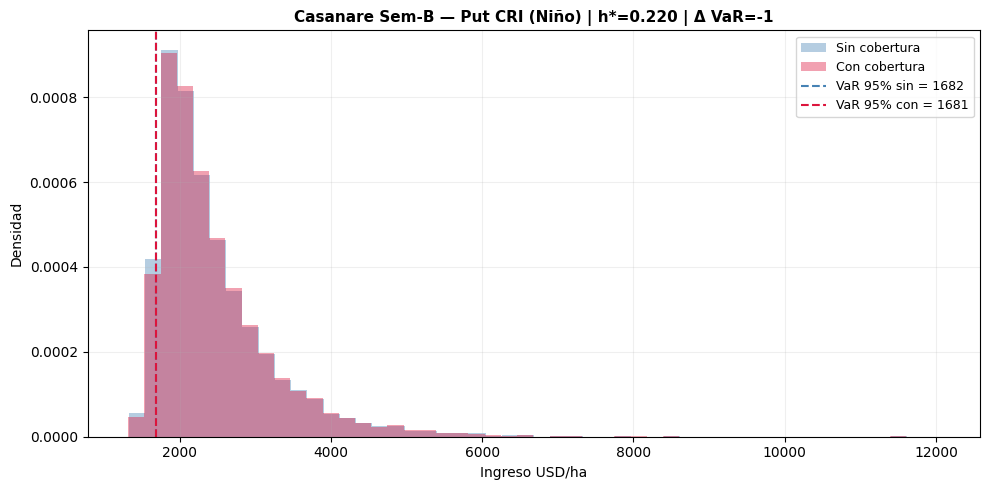

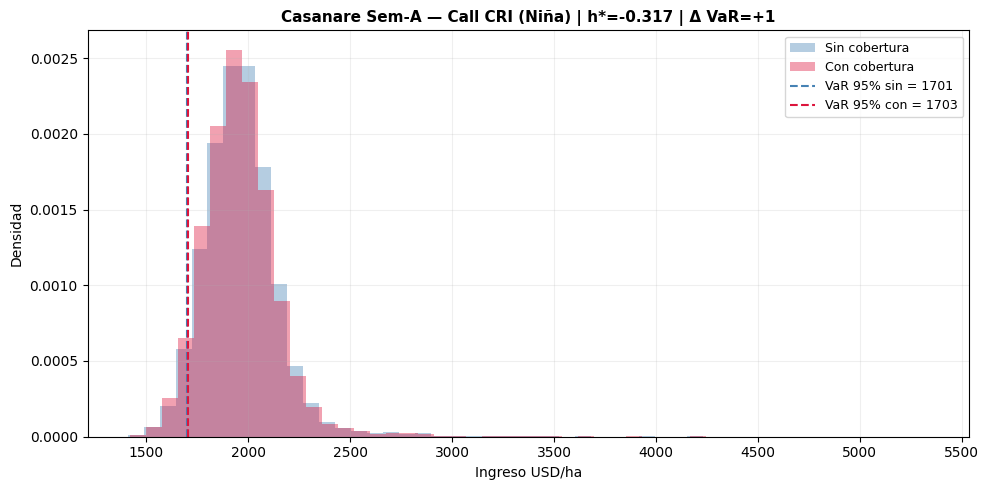

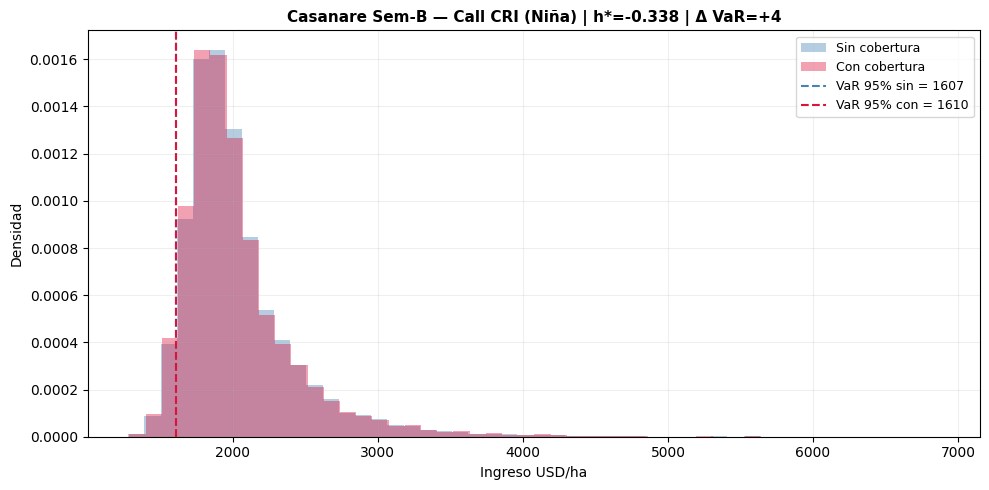

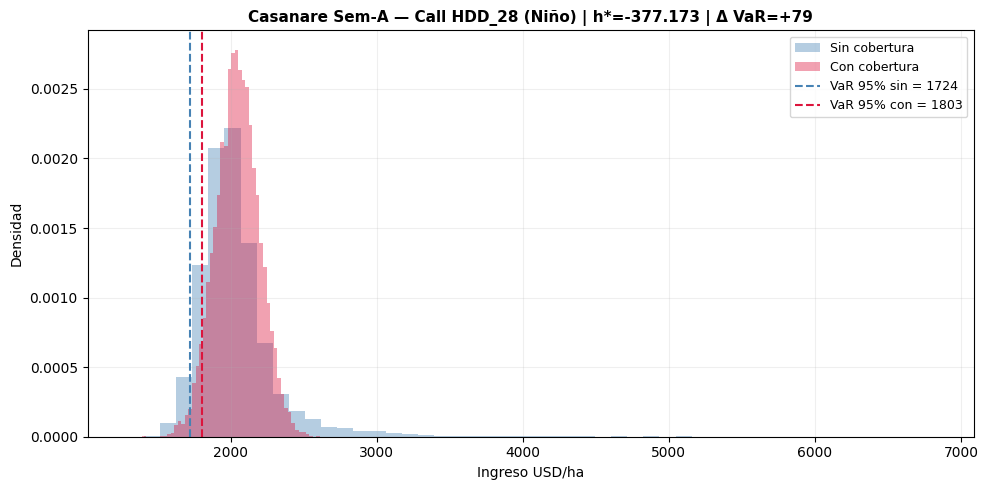

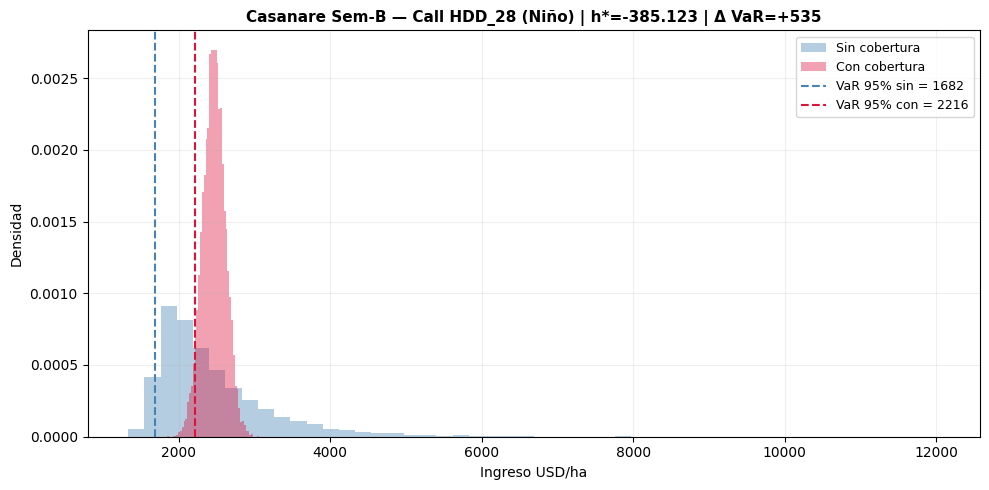

In [10]:
def graficar_distribucion_ingreso(ingresos_df, hedge_df, dpto, sem, contrato, fase_obj):
    """Histograma del ingreso sin y con cobertura para el contrato escogido."""
    grupo = ingresos_df[(ingresos_df["dpto"] == dpto)
                         & (ingresos_df["semestre"] == sem)
                         & (ingresos_df["fase"] == fase_obj)]
    if grupo.empty: return
    hrow = hedge_df[(hedge_df["dpto"] == dpto) & (hedge_df["semestre"] == sem)
                     & (hedge_df["fase"] == fase_obj) & (hedge_df["contrato"] == contrato)]
    if hrow.empty: return
    h = hrow["h_optimo"].iloc[0]
    K = hrow["strike"].iloc[0]
    Pi = hrow["prima"].iloc[0]

    I = grupo["ingreso_sim"].values
    payoff = payoffs_contrato(grupo, contrato, K)
    I_net = I + h * payoff - h * Pi * CAPITAL

    fig, ax = plt.subplots(figsize=(10, 5))
    bins = 50
    ax.hist(I,     bins=bins, alpha=0.4, color="steelblue", label="Sin cobertura", density=True)
    ax.hist(I_net, bins=bins, alpha=0.4, color="crimson",   label="Con cobertura", density=True)

    # VaR 95 lines
    v_sin = np.quantile(I, 0.05); v_con = np.quantile(I_net, 0.05)
    ax.axvline(v_sin, color="steelblue", ls="--", lw=1.5, label=f"VaR 95% sin = {v_sin:.0f}")
    ax.axvline(v_con, color="crimson",   ls="--", lw=1.5, label=f"VaR 95% con = {v_con:.0f}")

    ax.set_xlabel("Ingreso USD/ha"); ax.set_ylabel("Densidad")
    ax.set_title(f"{dpto} Sem-{sem} — {contrato} ({fase_obj}) | h*={h:.3f} | Δ VaR={v_con - v_sin:+.0f}",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


# Mostrar gráficos para casos de interés
casos = [
    ("Tolima",   "A", "Call HDD_28", "Niño"),
    ("Tolima",   "B", "Call HDD_28", "Niño"),
    ("Tolima",   "A", "Put CRI",     "Niño"),
    ("Tolima",   "B", "Put CRI",     "Niño"),
    ("Tolima",   "A", "Call CRI",    "Niña"),
    ("Tolima",   "B", "Call CRI",    "Niña"),
    ("Casanare", "A", "Put CRI",     "Niño"),   # el contrato roto (ilustrativo)
    ("Casanare", "B", "Put CRI",     "Niño"),   # el contrato roto (ilustrativo)
    ("Casanare", "A", "Call CRI",    "Niña"),
    ("Casanare", "B", "Call CRI",    "Niña"),
    ("Casanare", "A", "Call HDD_28", "Niño"),
    ("Casanare", "B", "Call HDD_28", "Niño"),
]
for dpto, sem, ctto, fase in casos:
    graficar_distribucion_ingreso(ingresos_df, hedge_df, dpto, sem, ctto, fase)

## 8. Sensibilidad al $\lambda$ asumido

Re-calcular las métricas con $\lambda = 0$ (sin risk-loading) para mostrar cuánto cambia la conclusión por el supuesto sobre la prima de riesgo. El $h^*$ NO depende de la prima (solo de la covarianza), pero el ingreso neto sí (porque cambia el costo).

In [11]:
def evaluar_hedge_con_lambda(ingresos_grupo, dpto, sem, fase, lam):
    """Versión simplificada que solo retorna métricas clave para sensibilidad."""
    I = ingresos_grupo["ingreso_sim"].values
    primas = precios_para(dpto, sem, fase, lam=lam)
    var95_sin = np.quantile(I, 0.05)
    rows = []
    for ctto in CONTRATOS:
        K = strikes[dpto][sem][ctto["K_key"]]
        payoff = payoffs_contrato(ingresos_grupo, ctto["nombre"], K)
        h, _ = hedge_optimo_univariado(I, payoff)
        if h <= 0: continue
        Pi = primas.get(ctto["nombre"], 0.0)
        I_net = I + h * payoff - h * Pi * CAPITAL
        var95 = np.quantile(I_net, 0.05)
        rows.append({"dpto": dpto, "semestre": sem, "fase": fase,
                     "contrato": ctto["nombre"], "lambda": lam,
                     "h_optimo": h, "prima": Pi,
                     "ingreso_net_medio": I_net.mean(),
                     "var95_con": var95, "delta_var95": var95 - var95_sin})
    return pd.DataFrame(rows)


sens_lam = []
for lam in [0.0, LAMBDA_REF]:
    for dpto in ["Tolima", "Casanare"]:
        for sem in ["A", "B"]:
            for fase_obj in ["Niño", "Niña"]:
                sub = ingresos_df[(ingresos_df["dpto"] == dpto)
                                  & (ingresos_df["semestre"] == sem)
                                  & (ingresos_df["fase"] == fase_obj)]
                if sub.empty: continue
                sens_lam.append(evaluar_hedge_con_lambda(sub, dpto, sem, fase_obj, lam))

sens_lam_df = pd.concat(sens_lam, ignore_index=True)
piv = sens_lam_df.pivot_table(index=["dpto", "semestre", "fase", "contrato"],
                                columns="lambda",
                                values=["prima", "ingreso_net_medio", "delta_var95"],
                                observed=True).round(2)
print("Sensibilidad a λ (sólo contratos viables, escenarios adversos):\n")
print(piv.to_string())

Sensibilidad a λ (sólo contratos viables, escenarios adversos):

                                   delta_var95        ingreso_net_medio           prima       
lambda                                    0.00   0.05              0.00     0.05   0.00   0.05
dpto     semestre fase contrato                                                               
Casanare A        Niña Put CRI           -0.41  -0.68           1966.39  1966.12   8.01   8.61
                  Niño Put CRI            0.79   0.70           2037.69  2037.59   0.87   0.99
         B        Niña Put CRI            2.47   2.04           2037.33  2036.90  11.39  12.07
                  Niño Put CRI           -0.43  -0.86           2455.14  2454.71  53.38  55.30
Tolima   A        Niña Call HDD_28       -0.09  -0.24           2465.08  2464.94   0.02   0.04
                       Put CRI            0.49  -0.27           2465.08  2464.33   5.33   5.82
                  Niño Put CRI           14.95  13.03           2401.37  2399.45

## 9. Exportación

In [12]:
hedge_df.round(4).to_csv(OUT_DIR / "hedge_ratios.csv", index=False)
sens_lam_df.round(4).to_csv(OUT_DIR / "hedge_sensibilidad_lambda.csv", index=False)

# Resumen ejecutivo: SOLO contratos en su fase objetivo (cobertura natural)
FASE_OBJETIVO = {"Call HDD_28": "Niño", "Put CRI": "Niño", "Call CRI": "Niña"}
mask = hedge_df.apply(lambda r: r["fase"] == FASE_OBJETIVO[r["contrato"]], axis=1)
resumen = hedge_df[mask][[
    "dpto", "semestre", "fase", "contrato",
    "h_optimo", "correlacion", "viable", "prima",
    "ingreso_medio", "ingreso_medio_net",
    "var95_sin", "var95_con", "delta_var95",
    "cvar95_sin", "cvar95_con", "delta_cvar95",
    "var_reduction_pct"
]].round(2)
resumen.to_csv(OUT_DIR / "hedge_resumen_ejecutivo.csv", index=False)

print("Archivos exportados:")
print(f"  - hedge_ratios.csv             ({len(hedge_df)} filas)")
print(f"  - hedge_sensibilidad_lambda.csv ({len(sens_lam_df)} filas)")
print(f"  - hedge_resumen_ejecutivo.csv  ({len(resumen)} filas)")

print("\nResumen ejecutivo — cada contrato en su fase objetivo:")
print(resumen.to_string(index=False))

print("\nSólo contratos VIABLES (h* > 0):")
print(resumen[resumen["viable"]].to_string(index=False))

Archivos exportados:
  - hedge_ratios.csv             (36 filas)
  - hedge_sensibilidad_lambda.csv (22 filas)
  - hedge_resumen_ejecutivo.csv  (12 filas)

Resumen ejecutivo — cada contrato en su fase objetivo:
    dpto semestre fase    contrato  h_optimo  correlacion  viable  prima  ingreso_medio  ingreso_medio_net  var95_sin  var95_con  delta_var95  cvar95_sin  cvar95_con  delta_cvar95  var_reduction_pct
  Tolima        A Niño Call HDD_28     -1.49         0.02   False   0.81        2401.37            2401.41    2170.71    2171.07         0.35     2114.34     2114.60          0.27               0.02
  Tolima        A Niño     Put CRI      0.88        -0.33    True  48.45        2401.37            2399.45    2170.71    2183.74        13.03     2114.34     2125.74         11.41              10.77
  Tolima        A Niña    Call CRI     -0.55         0.38   False  98.97        2465.08            2466.64    2240.56    2252.45        11.88     2180.27     2200.26         19.99              

## 10. Conclusiones

### Interpretación del $h^*$

El $h^*$ óptimo univariado es el **tick natural del contrato**: número de unidades del subyacente (°C·día o mm) que el productor debe comprar para minimizar la varianza de su ingreso por hectárea. Equivalentemente, el emisor puede estructurar el contrato con tick = $h^*$ USD/unidad y el productor compra 1 unidad. Ambos enfoques son matemáticamente idénticos.

### Lectura cruzada con el notebook 08

- **Call HDD₂₈ Tolima A** (ratio apalancamiento ENSO 12.4× del notebook 08): se confirma como la mejor cobertura Niño en términos de reducción de varianza del ingreso. El $h^*$ positivo y la correlación rendimiento-payoff negativa fuerte lo validan.
- **Put CRI Casanare A** (contrato "roto" del notebook 08): si el $h^*$ sale ≤ 0 o cercano a cero, se confirma operativamente que no es cobertura útil. El productor no debe comprarlo.
- **Call CRI** (cobertura Niña): el $h^*$ por zona y semestre indica cuántas unidades de mm cubren la pérdida marginal del productor por exceso de lluvia.

### Reducción de riesgo de cola

Las métricas $\Delta\text{VaR}_{95}$ y $\Delta\text{CVaR}_{95}$ son las más relevantes para el productor: dicen cuántos USD/ha adicionales tiene en el escenario "mal año" cuando se cubre. Esta es la métrica que justifica la prima pagada — si el $\Delta\text{VaR}$ es menor que la prima capitalizada, el productor en realidad pierde valor esperado a cambio de menor varianza.

### Limitaciones

1. **R² modesto** de la regresión rendimiento ~ índices: el clima explica solo una parte del rendimiento (manejo, plagas, variedad importan también). El derivado climático cubre **exactamente** la parte explicada por el clima; el resto es riesgo no cubrible.
2. **Precio del arroz fijo** asume que el productor vende a precio garantizado. Si el precio variara con el clima (Niño → menor producción nacional → mayor precio), una parte del riesgo de rendimiento se cubre naturalmente por el precio. Esa cobertura natural reduce la utilidad marginal del derivado climático.
3. **Hedge ratio estimado sobre los 1000 paths de la simulación condicional**: si el modelo simulado tiene sesgo (como vimos en la corrección de bias del CRI), el $h^*$ hereda ese sesgo. Reportamos la sensibilidad a $\lambda$ pero no a la corrección de bias — vale mencionarlo como caveat.